In [2]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "/home/haz124/teams/z2/data/steam/cleaned/steam_reviews_full_with_genres.parquet"
pf = pq.ParquetFile(file_path)

1. Data overview

In [4]:
pf.num_row_groups

165

In [5]:
pf.schema

required group field_id=-1 schema {
  optional int64 field_id=-1 recommendationid;
  optional int64 field_id=-1 appid;
  optional binary field_id=-1 game (String);
  optional binary field_id=-1 author_steamid (String);
  optional int64 field_id=-1 author_num_games_owned;
  optional int64 field_id=-1 author_num_reviews;
  optional int64 field_id=-1 author_playtime_forever;
  optional int64 field_id=-1 author_playtime_last_two_weeks;
  optional int64 field_id=-1 author_playtime_at_review;
  optional int64 field_id=-1 author_last_played (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional binary field_id=-1 language (String);
  optional binary field_id=-1 review (String);
  optional int64 field_id=-1 timestamp_created (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional int64 field_id=-1 timestamp_updated (Timestamp(isAdjustedToUTC=fal

In [6]:
df = pf.read_row_group(0).to_pandas()
df.head()

,recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,...,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location,Game_Genres
0,148919893,10,Counter-Strike,76561199036724879,0,3,197,197,197,2023-10-26 16:06:09,...,0,0,0.0,0,True,False,False,True,<NA>,[Action]
1,148919350,10,Counter-Strike,76561198826729322,0,21,441,37,441,2023-10-26 15:56:49,...,0,0,0.0,0,True,False,False,True,<NA>,[Action]
2,148913051,10,Counter-Strike,76561199101237625,7,1,1440,1440,1313,2023-10-26 16:43:55,...,0,0,0.0,0,True,False,False,True,<NA>,[Action]
3,148912714,10,Counter-Strike,76561198347582422,11,4,1636,83,1612,2023-10-26 17:37:14,...,0,0,0.0,0,True,False,False,True,<NA>,[Action]
4,148912575,10,Counter-Strike,76561198363716821,0,2,197,41,197,2023-10-26 14:10:01,...,0,0,0.0,0,True,False,False,True,<NA>,[Action]


2. Data Structure

   This sub-dataset contains 712710 rows and 24 columns including numeric, bool, timestamp, string variables.

In [7]:
df.shape

(712710, 25)

In [8]:
df.dtypes

recommendationid                           Int64
appid                                      int64
game                              string[python]
author_steamid                    string[python]
author_num_games_owned                     Int64
author_num_reviews                         Int64
author_playtime_forever                    Int64
author_playtime_last_two_weeks             Int64
author_playtime_at_review                  Int64
author_last_played                datetime64[ns]
language                          string[python]
review                            string[python]
timestamp_created                 datetime64[ns]
timestamp_updated                 datetime64[ns]
voted_up                                    bool
votes_up                                   Int64
votes_funny                                Int64
weighted_vote_score                      float32
comment_count                              Int64
steam_purchase                              bool
received_for_free   

3. Missing values
   
   The steam_china_location column has no values, and the review column has a missing rate of 0.0007%, which is very small. All other columns are fully filled.

In [9]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate 

steam_china_location              1.000000
Game_Genres                       0.064283
review                            0.000007
timestamp_updated                 0.000000
hidden_in_steam_china             0.000000
written_during_early_access       0.000000
received_for_free                 0.000000
steam_purchase                    0.000000
comment_count                     0.000000
weighted_vote_score               0.000000
votes_funny                       0.000000
votes_up                          0.000000
voted_up                          0.000000
recommendationid                  0.000000
appid                             0.000000
language                          0.000000
author_last_played                0.000000
author_playtime_at_review         0.000000
author_playtime_last_two_weeks    0.000000
author_playtime_forever           0.000000
author_num_reviews                0.000000
author_num_games_owned            0.000000
author_steamid                    0.000000
game       

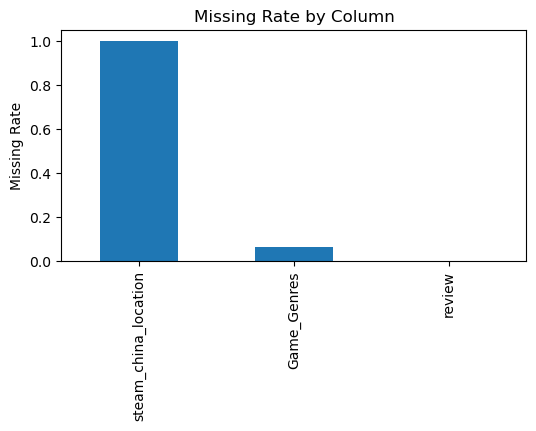

In [10]:
missing_rate[missing_rate > 0].plot.bar(figsize=(6,3))
plt.ylabel("Missing Rate")
plt.title("Missing Rate by Column")
plt.show()

4. numerical features distributions

   Most numerical features are right-skewed.
   Most values are small, while a few have very large values. This pattern is common for count-based variables such as votes_up, votes_funny, comment_count and author_playtime_forever. These extreme values may affect modeling, so outlier should be considered.
   And the weighted_vote_score's distribution is a bit interesting, the score mostly concentrated at low values, with a smaller peak at around 0.4-0.6. This shows most reviews have low confidence scores, while a small portion of reviews receive strong positive feedback.

In [11]:
num_cols = [
    "votes_up",
    "votes_funny",
    "comment_count",
    "weighted_vote_score",
    "author_playtime_forever"
]

df[num_cols].describe()

,votes_up,votes_funny,comment_count,weighted_vote_score,author_playtime_forever
count,712710.0,712710.0,712710.0,712710.000000,712710.0
mean,2.533973,72315.751184,0.114688,0.198647,18928.22887
std,26.340229,17623440.896502,1.216709,0.259445,67816.724526
min,0.0,0.0,0.0,0.000000,0.0
25%,0.0,0.0,0.0,0.000000,296.0
50%,0.0,0.0,0.0,0.000000,1122.0
75%,1.0,0.0,0.0,0.502392,5864.75
max,7796.0,4294967295.0,293.0,0.992070,5839020.0


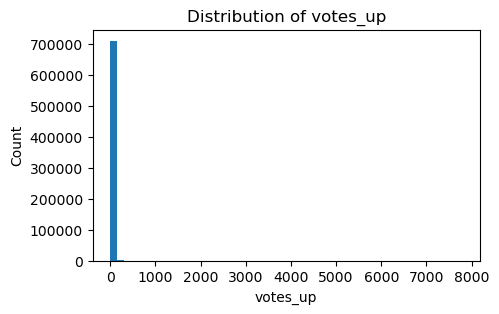

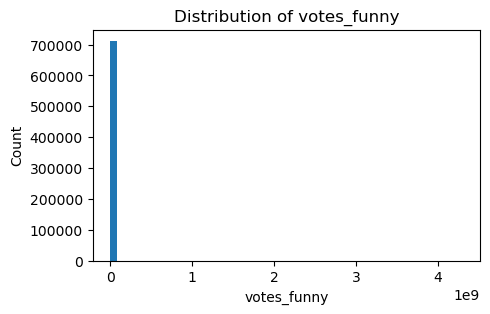

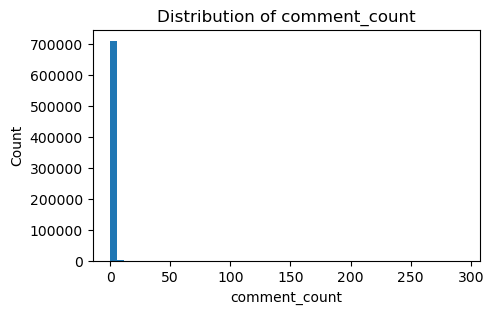

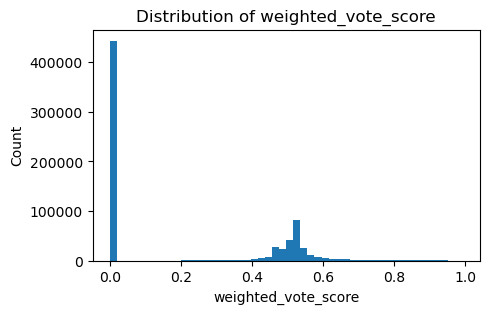

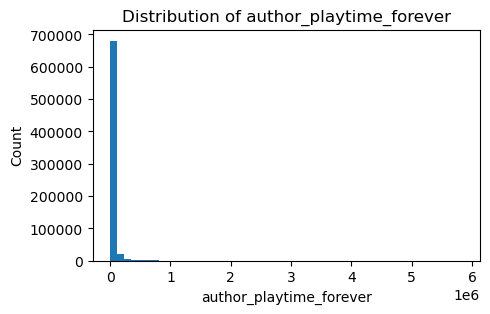

In [12]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(),bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

5. Boolean 

   Overall, boolean features show reasonable distributions.
   About 88.7% reviews are positive, and 67.9% of reviews are from users who purchased the game on Steam.
   Only 17.5% of games are hidden in China, and 12% of reviews are written during early access. Only 4.4% of reviews are from users who received the game for free.

In [13]:
bool_cols = [
    "voted_up",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "hidden_in_steam_china"
]

In [14]:
df[bool_cols].mean().sort_values(ascending=False)

voted_up                       0.887228
steam_purchase                 0.678879
hidden_in_steam_china          0.174785
written_during_early_access    0.120111
received_for_free              0.043622
dtype: float64

6. Categorical

   The most used language of user riviews is English.
   Riview counts are concentrated in small number of games, showing a long-tail parttern.
   Some categorical fields, such as steam_china_location, have many missing values, which is expected.

In [15]:
df["language"].value_counts().head(10)

language
english      286739
russian      111770
schinese      84846
spanish       46804
turkish       28727
brazilian     28683
polish        24091
german        20319
french        13625
tchinese      11444
Name: count, dtype: Int64

In [16]:
df["game"].value_counts().head(10)

game
Counter-Strike                           225622
Call of Duty: Modern Warfare 2 (2009)     53782
Call of Duty: World at War                46171
The Long Drive                            26393
Devotion                                  17754
Unrailed!                                 16712
War Selection                             16039
60 Seconds! Reatomized                    12093
Age of Empires: Definitive Edition        11657
Chernobylite Enhanced Edition             11355
Name: count, dtype: Int64

In [17]:
top_games = df["game"].value_counts(normalize=True).head(10)
top_games

game
Counter-Strike                           0.316569
Call of Duty: Modern Warfare 2 (2009)    0.075461
Call of Duty: World at War               0.064782
The Long Drive                           0.037032
Devotion                                 0.024911
Unrailed!                                0.023449
War Selection                            0.022504
60 Seconds! Reatomized                   0.016968
Age of Empires: Definitive Edition       0.016356
Chernobylite Enhanced Edition            0.015932
Name: proportion, dtype: Float64

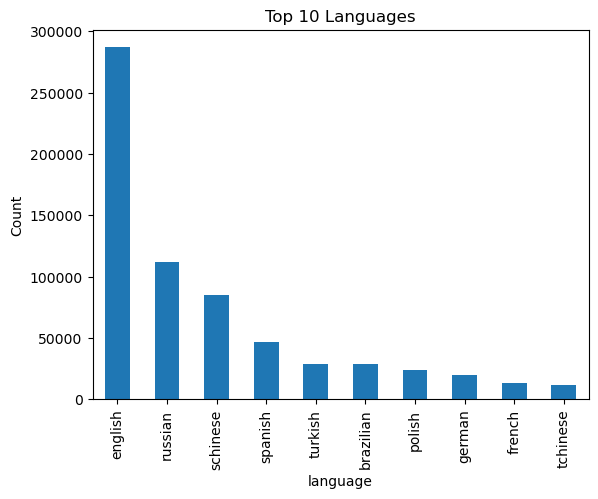

In [18]:
df["language"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Languages")
plt.ylabel("Count")
plt.show()

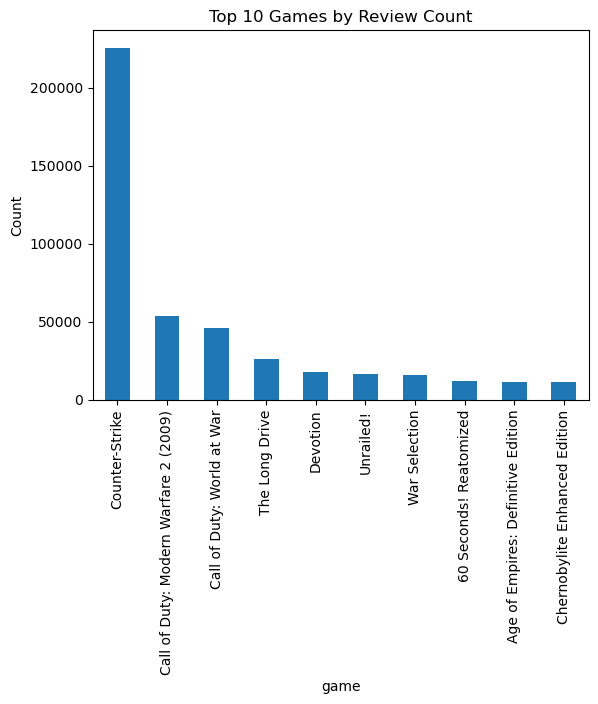

In [19]:
df["game"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Games by Review Count")
plt.ylabel("Count")
plt.show()

In [20]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("/home/haz124/teams/z2/data/steam/cleaned/steam_reviews_full_with_genres.parquet")
print("Total reviews:", pf.metadata.num_rows)


Total reviews: 113883717


In [21]:
import pyarrow.parquet as pq
import pyarrow.compute as pc

path = "/home/haz124/teams/z2/data/steam/cleaned/steam_reviews_full_with_genres.parquet"
pf = pq.ParquetFile(path)

total = 0
missing = 0

for rg in range(pf.num_row_groups):
    col = pf.read_row_group(rg, columns=["Game_Genres"])["Game_Genres"]
    total += len(col)
    missing += pc.sum(pc.is_null(col)).as_py()

print("Missing genres rate:", missing / total)
print("total rows:", total)


Missing genres rate: 0.04470573260266874
total rows: 113883717


In [ ]:
import pandas as pd

sample = pd.read_parquet(
    "/home/haz124/teams/z2/data/steam/cleaned/steam_reviews_full_with_genres.parquet",
    columns=["appid", "Game_Genres"],
    engine="pyarrow"
)

print("Missing genres rate:", sample["Game_Genres"].isna().mean())
